# 03 — Candidate walking-route PM₂.₅ exposure in Helsinki

**Purpose.** Extend the OD-based analysis from destination exposure to exposure along modeled candidate walking routes. The notebook reproduces the minimum CAFEIN/FMI preprocessing needed to identify route-ready OD pairs, then uses OSMnx to route the five largest test flows and samples PM₂.₅ every 20 m along each route.

**Important:** CAFEIN OD flows do not identify travel mode or observed trajectories. The routes below are therefore **candidate shortest walking routes**, not observed walking trips.


## 1. Re-create the minimum CAFEIN/FMI preparation needed for routing

This intentionally repeats a small amount of Notebook 02 so this notebook can run independently in a fresh kernel.


In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

import cafein.sampledata.helsinki as helsinki

print("Air quality:", helsinki.air_quality)
print("OD weekday:", helsinki.mobility.od_weekday)
print("Presence weekday:", helsinki.mobility.presence_weekday)
print("Neighbourhoods:", helsinki.mobility.neighbourhoods)

Air quality: /users/modjrian/.cache/x86_64/cafein-sampledata/helsinki/helsinki-2026.08.4/e9e1a0a02590aae38aaaef126cbfc39c38e788e7e9f9390f9234c9f3461b6b4e/helsinki_air_quality.tif
OD weekday: /users/modjrian/.cache/x86_64/cafein-sampledata/helsinki/helsinki-2026.08.4/c9f14f987a0203898eee0f6bd8f95644d87f7df8c503eba6fe059989a6d3ddd8/hma_od_weekday.parquet
Presence weekday: /users/modjrian/.cache/x86_64/cafein-sampledata/helsinki/helsinki-2026.08.4/ab61a25d529672b95bc1e0a3ad6807d932fd0d05dcc7f92756bcd049c6b14c7d/hma_presence_weekday.parquet
Neighbourhoods: /users/modjrian/.cache/x86_64/cafein-sampledata/helsinki/helsinki-2026.08.4/2f21e21c101e22c87730a30b6283df436f41eb3728758f9734269f237fc2f016/hma_neighbourhoods.gpkg


In [2]:
od = pd.read_parquet(helsinki.mobility.od_weekday)
presence = pd.read_parquet(helsinki.mobility.presence_weekday)
units = gpd.read_file(helsinki.mobility.neighbourhoods)

print("OD:", od.shape, od.columns.tolist())
print("Presence:", presence.shape, presence.columns.tolist())
print("Units:", units.shape, units.columns.tolist(), units.crs)

display(od.head())
display(presence.head())
display(units.head())

OD: (1580938, 4) ['origin', 'destination', 'hour', 'trips']
Presence: (1587394, 4) ['home_unit', 'visited_unit', 'hour', 'presence']
Units: (298, 4) ['Neighbourhood_unit_ID', 'Neighbourhood_name', 'Municipality_name', 'geometry'] EPSG:3067


,origin,destination,hour,trips
0,491011111,491011112,0,59.896716
1,491011111,491011113,0,39.964573
2,491011111,491011114,0,4.011500
3,491011111,491011115,0,10.129039
4,491011111,491011116,0,17.086485


,home_unit,visited_unit,hour,presence
0,491011111,491011111,0,5005.913787
1,491011111,491011112,0,59.896716
2,491011111,491011113,0,39.964573
3,491011111,491011114,0,4.011500
4,491011111,491011115,0,10.129039


,Neighbourhood_unit_ID,Neighbourhood_name,Municipality_name,geometry
0,491011111.0,Pohjois-Leppävaara,Espoo,"MULTIPOLYGON (((379595.15 6678747.999, 379562...."
1,491011112.0,Etelä-Leppävaara,Espoo,"MULTIPOLYGON (((379029.254 6677829.657, 379007..."
2,491011113.0,Mäkkylä,Espoo,"MULTIPOLYGON (((380257.535 6678941.217, 380259..."
3,491011114.0,Lintukorpi,Espoo,"MULTIPOLYGON (((379115.695 6679654.899, 379115..."
4,491011115.0,Lintulaakso,Espoo,"MULTIPOLYGON (((380218.977 6679301.685, 380254..."


In [3]:
units["unit_id"] = units["Neighbourhood_unit_ID"].astype("Int64")

presence["home_unit"] = presence["home_unit"].astype("Int64")
presence["visited_unit"] = presence["visited_unit"].astype("Int64")

od["origin"] = od["origin"].astype("Int64")
od["destination"] = od["destination"].astype("Int64")

unit_lookup = units[
    ["unit_id", "Neighbourhood_name", "Municipality_name", "geometry"]
].copy()

In [4]:
origin_names = unit_lookup[
    ["unit_id", "Neighbourhood_name"]
].rename(columns={
    "unit_id": "origin",
    "Neighbourhood_name": "origin_name"
})

destination_names = unit_lookup[
    ["unit_id", "Neighbourhood_name"]
].rename(columns={
    "unit_id": "destination",
    "Neighbourhood_name": "destination_name"
})

od_geo = (
    od
    .merge(origin_names, on="origin", how="left")
    .merge(destination_names, on="destination", how="left")
)

display(od_geo.head())

print("Missing origin names:", od_geo["origin_name"].isna().sum())
print("Missing destination names:", od_geo["destination_name"].isna().sum())

,origin,destination,hour,trips,origin_name,destination_name
0,491011111,491011112,0,59.896716,Pohjois-Leppävaara,Etelä-Leppävaara
1,491011111,491011113,0,39.964573,Pohjois-Leppävaara,Mäkkylä
2,491011111,491011114,0,4.011500,Pohjois-Leppävaara,Lintukorpi
3,491011111,491011115,0,10.129039,Pohjois-Leppävaara,Lintulaakso
4,491011111,491011116,0,17.086485,Pohjois-Leppävaara,Uusmäki


Missing origin names: 0
Missing destination names: 0


In [5]:
with rasterio.open(helsinki.air_quality) as src:
    print("CRS:", src.crs)
    print("NoData:", src.nodata)
    print("Bounds:", src.bounds)
    print("Band 5:", src.descriptions[4])

    pm = src.read(5, masked=True)
    print("Valid min:", float(pm.min()))
    print("Valid max:", float(pm.max()))
    print("Valid mean:", float(pm.mean()))

CRS: EPSG:4326
NoData: None
Bounds: BoundingBox(left=24.579882090898522, bottom=60.36805850867299, right=25.199918324140544, top=60.132040673455926)
Band 5: PM25Concentration [ug/m3]
Valid min: 1.899999976158142
Valid max: 5.300000190734863
Valid mean: 2.537067174911499


In [6]:
unit_pm = units[
    ["unit_id", "Neighbourhood_name", "Municipality_name", "geometry"]
].copy()

with rasterio.open(helsinki.air_quality) as src:
    # Put polygons in the raster CRS (EPSG:4326 for this sample)
    unit_pm = unit_pm.to_crs(src.crs)

    # Guaranteed to lie inside each polygon
    unit_pm["sample_point"] = unit_pm.geometry.representative_point()

    # Raster bounds can have reversed y ordering, so normalize them
    xmin = min(src.bounds.left, src.bounds.right)
    xmax = max(src.bounds.left, src.bounds.right)
    ymin = min(src.bounds.bottom, src.bounds.top)
    ymax = max(src.bounds.bottom, src.bounds.top)

    def sample_pm25(point):
        x, y = point.x, point.y

        # Explicit out-of-bounds protection
        if not (xmin <= x <= xmax and ymin <= y <= ymax):
            return np.nan

        value = next(
            src.sample([(x, y)], indexes=5, masked=True)
        )[0]

        if np.ma.is_masked(value):
            return np.nan

        value = float(value)

        # Safety check based on the actual raster: zero is not a valid value here
        if value <= 0:
            return np.nan

        return value

    unit_pm["pm25"] = unit_pm["sample_point"].apply(sample_pm25)

print("Minimum:", unit_pm["pm25"].min())
print("Maximum:", unit_pm["pm25"].max())
print("Missing neighbourhoods:", unit_pm["pm25"].isna().sum())

display(
    unit_pm[
        ["unit_id", "Neighbourhood_name", "Municipality_name", "pm25"]
    ].head(20)
)

Minimum: 1.899999976158142
Maximum: 5.199999809265137
Missing neighbourhoods: 14


,unit_id,Neighbourhood_name,Municipality_name,pm25
0,491011111,Pohjois-Leppävaara,Espoo,2.6
1,491011112,Etelä-Leppävaara,Espoo,2.3
2,491011113,Mäkkylä,Espoo,2.4
3,491011114,Lintukorpi,Espoo,2.3
4,491011115,Lintulaakso,Espoo,2.7
5,491011116,Uusmäki,Espoo,2.6
6,491011117,Lintumetsä,Espoo,2.6
7,491011118,Perkkaa,Espoo,2.7
8,491013131,Nuijala,Espoo,2.6
9,491013132,Kuninkainen,Espoo,2.6


In [7]:
missing_units = unit_pm.loc[
    unit_pm["pm25"].isna(),
    ["unit_id", "Neighbourhood_name", "Municipality_name"]
]

display(missing_units)

,unit_id,Neighbourhood_name,Municipality_name
34,493031316,Miessaari,Espoo
44,494041415,Soukanniemi,Espoo
55,494045451,Suvisaaret,Espoo
56,494045452,Ulkosaaret,Espoo
58,495051512,Espoonkartano,Espoo
75,496064643,Siikajärvi,Espoo
77,496064645,Ämmässuo,Espoo
98,911102531,Länsisaaret,Helsinki
207,916603532,Itäsaaret,Helsinki
208,916603533,Aluemeri,Helsinki


## 2. Prepare OD pairs with valid origin and destination PM₂.₅


In [8]:
origin_pm_for_od = unit_pm[
    ["unit_id", "pm25"]
].rename(columns={
    "unit_id": "origin",
    "pm25": "origin_pm25"
})

destination_pm_for_od = unit_pm[
    ["unit_id", "pm25"]
].rename(columns={
    "unit_id": "destination",
    "pm25": "destination_pm25"
})

route_od = (
    od_geo
    .merge(origin_pm_for_od, on="origin", how="left")
    .merge(destination_pm_for_od, on="destination", how="left")
)

route_od = route_od[
    route_od["origin_pm25"].notna() &
    route_od["destination_pm25"].notna() &
    (route_od["origin"] != route_od["destination"])
].copy()

od_pairs = (
    route_od
    .groupby(
        ["origin", "origin_name", "destination", "destination_name"],
        as_index=False
    )
    .agg(trips=("trips", "sum"))
)

top_pairs = (
    od_pairs
    .sort_values("trips", ascending=False)
    .head(100)
    .copy()
)

print("Route-ready OD pairs:", len(od_pairs))
display(top_pairs.head(20))

Route-ready OD pairs: 71897


,origin,origin_name,destination,destination_name,trips
25613,911103203,Jätkäsaari,911103040,Kamppi,7833.721931
25050,911103130,Etu-Töölö,911103040,Kamppi,7708.390583
25896,911104140,Taka-Töölö,911103130,Etu-Töölö,7561.684670
57997,921015000,Myyrmäki,921017000,Martinlaakso,7375.596901
23105,911102050,Punavuori,911103040,Kamppi,7267.193618
58559,921017000,Martinlaakso,921015000,Myyrmäki,7079.997889
25895,911104140,Taka-Töölö,911103040,Kamppi,6596.702289
23665,911102070,Ullanlinna,911103040,Kamppi,6541.456357
25054,911103130,Etu-Töölö,911104140,Taka-Töölö,6262.630766
25041,911103130,Etu-Töölö,911101020,Kluuvi,5988.508767


In [9]:
points = unit_pm[
    ["unit_id", "sample_point"]
].copy()

origin_points = points.rename(columns={
    "unit_id": "origin",
    "sample_point": "origin_point"
})

destination_points = points.rename(columns={
    "unit_id": "destination",
    "sample_point": "destination_point"
})

top_pairs = (
    top_pairs
    .merge(origin_points, on="origin", how="left")
    .merge(destination_points, on="destination", how="left")
)

test_pairs = top_pairs.head(5).copy()

display(
    test_pairs[
        [
            "origin_name",
            "destination_name",
            "trips",
            "origin_point",
            "destination_point"
        ]
    ]
)

print("Point CRS: EPSG:4326 / longitude-latitude")
print("Ready for OSMnx; OSMnx has not been called in this notebook.")

,origin_name,destination_name,trips,origin_point,destination_point
0,Jätkäsaari,Kamppi,7833.721931,POINT (24.91016 60.15291),POINT (24.93206 60.16631)
1,Etu-Töölö,Kamppi,7708.390583,POINT (24.91024 60.17426),POINT (24.93206 60.16631)
2,Taka-Töölö,Etu-Töölö,7561.684670,POINT (24.9188 60.18405),POINT (24.91024 60.17426)
3,Myyrmäki,Martinlaakso,7375.596901,POINT (24.84974 60.26366),POINT (24.85049 60.28131)
4,Punavuori,Kamppi,7267.193618,POINT (24.93496 60.16106),POINT (24.93206 60.16631)


Point CRS: EPSG:4326 / longitude-latitude
Ready for OSMnx; OSMnx has not been called in this notebook.


# 3. Active-travel routing with OSMnx

This section preserves the original routing workflow. The first network download requires internet access to query OpenStreetMap/Overpass.


In [10]:
# Run once if OSMnx is not installed, then restart the kernel if prompted.
%pip install -U osmnx

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [11]:
import osmnx as ox
from shapely.geometry import box
from shapely.ops import linemerge

print("OSMnx version:", ox.__version__)

OSMnx version: 2.1.1


## 3.1 Build a walking-network download polygon around the five OD pairs


In [12]:
# Collect all origin and destination points
od_points = gpd.GeoDataFrame(
    geometry=(
        list(test_pairs["origin_point"]) +
        list(test_pairs["destination_point"])
    ),
    crs="EPSG:4326"
)

# Work in Finnish metric CRS for a sensible buffer
od_points_3067 = od_points.to_crs("EPSG:3067")

xmin, ymin, xmax, ymax = od_points_3067.total_bounds

# Bounding rectangle around all test points + 2 km network margin
download_polygon_3067 = box(
    xmin, ymin, xmax, ymax
).buffer(2000)

download_polygon = (
    gpd.GeoSeries(
        [download_polygon_3067],
        crs="EPSG:3067"
    )
    .to_crs("EPSG:4326")
    .iloc[0]
)

print("Network download polygon ready.")

Network download polygon ready.


## 3.2 Download the OpenStreetMap walking network


In [13]:
G_walk = ox.graph.graph_from_polygon(
    download_polygon,
    network_type="walk",
    simplify=True
)

print("Nodes:", len(G_walk.nodes))
print("Edges:", len(G_walk.edges))
print("Graph CRS:", G_walk.graph["crs"])

Nodes: 94881
Edges: 242440
Graph CRS: epsg:4326


## 3.3 Project the graph and OD points to EPSG:3067


In [14]:
G_walk_proj = ox.projection.project_graph(
    G_walk,
    to_crs="EPSG:3067"
)

origins = gpd.GeoDataFrame(
    test_pairs[
        ["origin_name", "destination_name", "trips"]
    ].copy(),
    geometry=list(test_pairs["origin_point"]),
    crs="EPSG:4326"
).to_crs("EPSG:3067")

destinations = gpd.GeoDataFrame(
    test_pairs[
        ["origin_name", "destination_name", "trips"]
    ].copy(),
    geometry=list(test_pairs["destination_point"]),
    crs="EPSG:4326"
).to_crs("EPSG:3067")

print("Projected graph CRS:", G_walk_proj.graph["crs"])

Projected graph CRS: EPSG:3067


## 3.4 Snap OD points to the nearest walking-network nodes


In [15]:
orig_nodes, orig_snap_dist = ox.distance.nearest_nodes(
    G_walk_proj,
    X=origins.geometry.x.to_numpy(),
    Y=origins.geometry.y.to_numpy(),
    return_dist=True
)

dest_nodes, dest_snap_dist = ox.distance.nearest_nodes(
    G_walk_proj,
    X=destinations.geometry.x.to_numpy(),
    Y=destinations.geometry.y.to_numpy(),
    return_dist=True
)

route_input = test_pairs[
    ["origin_name", "destination_name", "trips"]
].copy()

route_input["orig_node"] = orig_nodes
route_input["dest_node"] = dest_nodes
route_input["origin_snap_m"] = orig_snap_dist
route_input["destination_snap_m"] = dest_snap_dist

display(route_input)

print(
    "Maximum origin snap distance:",
    round(route_input["origin_snap_m"].max(), 1),
    "m"
)
print(
    "Maximum destination snap distance:",
    round(route_input["destination_snap_m"].max(), 1),
    "m"
)

,origin_name,destination_name,trips,orig_node,dest_node,origin_snap_m,destination_snap_m
0,Jätkäsaari,Kamppi,7833.721931,6537525622,7702050788,1.111745,8.614675
1,Etu-Töölö,Kamppi,7708.390583,1385777460,7702050788,10.841985,8.614675
2,Taka-Töölö,Etu-Töölö,7561.684670,2622160902,1385777460,28.807544,10.841985
3,Myyrmäki,Martinlaakso,7375.596901,12967108961,1096430061,34.392682,22.628950
4,Punavuori,Kamppi,7267.193618,248951364,7702050788,15.838266,8.614675


Maximum origin snap distance: 34.4 m
Maximum destination snap distance: 22.6 m


Large snap distances are a warning that a neighbourhood representative point is not close to the walk network. For this prototype, inspect the values before interpreting a route.

## 3.5 Solve the shortest walking routes


In [16]:
paths = ox.routing.shortest_path(
    G_walk_proj,
    route_input["orig_node"].tolist(),
    route_input["dest_node"].tolist(),
    weight="length",
    cpus=1
)

route_input["path"] = paths
route_input["route_found"] = route_input["path"].apply(
    lambda x: x is not None
)

display(
    route_input[
        [
            "origin_name",
            "destination_name",
            "trips",
            "origin_snap_m",
            "destination_snap_m",
            "route_found"
        ]
    ]
)

print(
    "Routes found:",
    int(route_input["route_found"].sum()),
    "of",
    len(route_input)
)

,origin_name,destination_name,trips,origin_snap_m,destination_snap_m,route_found
0,Jätkäsaari,Kamppi,7833.721931,1.111745,8.614675,True
1,Etu-Töölö,Kamppi,7708.390583,10.841985,8.614675,True
2,Taka-Töölö,Etu-Töölö,7561.684670,28.807544,10.841985,True
3,Myyrmäki,Martinlaakso,7375.596901,34.392682,22.628950,True
4,Punavuori,Kamppi,7267.193618,15.838266,8.614675,True


Routes found: 5 of 5


## 3.6 Convert each path to a route geometry


In [17]:
route_records = []

for idx, row in route_input.iterrows():

    if row["path"] is None:
        continue

    edges = ox.routing.route_to_gdf(
        G_walk_proj,
        row["path"],
        weight="length"
    )

    # Merge the ordered edge geometries into one linear route geometry.
    route_geom = linemerge(list(edges.geometry))

    route_records.append({
        "origin_name": row["origin_name"],
        "destination_name": row["destination_name"],
        "trips": row["trips"],
        "origin_snap_m": row["origin_snap_m"],
        "destination_snap_m": row["destination_snap_m"],
        "route_length_m": float(edges["length"].sum()),
        "geometry": route_geom
    })

routes = gpd.GeoDataFrame(
    route_records,
    geometry="geometry",
    crs="EPSG:3067"
)

display(
    routes[
        [
            "origin_name",
            "destination_name",
            "trips",
            "route_length_m",
            "origin_snap_m",
            "destination_snap_m"
        ]
    ]
)

,origin_name,destination_name,trips,route_length_m,origin_snap_m,destination_snap_m
0,Jätkäsaari,Kamppi,7833.721931,2296.663348,1.111745,8.614675
1,Etu-Töölö,Kamppi,7708.390583,1695.582480,10.841985,8.614675
2,Taka-Töölö,Etu-Töölö,7561.684670,1496.325861,28.807544,10.841985
3,Myyrmäki,Martinlaakso,7375.596901,2701.772427,34.392682,22.628950
4,Punavuori,Kamppi,7267.193618,914.605465,15.838266,8.614675


## 3.7 Sample PM₂.₅ every 20 m along each walking route

Because the FMI sample raster is a single model hour, this remains a **spatial route-exposure proof of concept**, not a time-varying trip-exposure estimate.


In [18]:
def sample_route_pm25(route_geom, raster_path, spacing_m=20):

    if route_geom is None or route_geom.is_empty:
        return {
            "mean_route_pm25": np.nan,
            "min_route_pm25": np.nan,
            "max_route_pm25": np.nan,
            "valid_pm25_samples": 0,
            "pm25_sample_coverage_pct": 0.0
        }

    # For a route geometry in EPSG:3067, sample at near-regular distances.
    total_length = route_geom.length

    distances = np.arange(
        0,
        total_length,
        spacing_m
    )

    # Always include the endpoint
    distances = np.append(distances, total_length)

    sample_points = [
        route_geom.interpolate(d)
        for d in distances
    ]

    pts = gpd.GeoDataFrame(
        geometry=sample_points,
        crs="EPSG:3067"
    )

    with rasterio.open(raster_path) as src:

        pts_raster = pts.to_crs(src.crs)

        xmin = min(src.bounds.left, src.bounds.right)
        xmax = max(src.bounds.left, src.bounds.right)
        ymin = min(src.bounds.bottom, src.bounds.top)
        ymax = max(src.bounds.bottom, src.bounds.top)

        values = []

        for point in pts_raster.geometry:

            x, y = point.x, point.y

            # Explicitly protect against the raster's undefined out-of-bounds fill
            if not (xmin <= x <= xmax and ymin <= y <= ymax):
                values.append(np.nan)
                continue

            value = next(
                src.sample(
                    [(x, y)],
                    indexes=5,
                    masked=True
                )
            )[0]

            if np.ma.is_masked(value):
                values.append(np.nan)
                continue

            value = float(value)

            # Raster valid values are positive; zero indicates no valid sample here
            if value <= 0:
                values.append(np.nan)
            else:
                values.append(value)

    values = np.asarray(values, dtype=float)
    valid = values[np.isfinite(values)]

    if len(valid) == 0:
        return {
            "mean_route_pm25": np.nan,
            "min_route_pm25": np.nan,
            "max_route_pm25": np.nan,
            "valid_pm25_samples": 0,
            "pm25_sample_coverage_pct": 0.0
        }

    return {
        "mean_route_pm25": float(np.mean(valid)),
        "min_route_pm25": float(np.min(valid)),
        "max_route_pm25": float(np.max(valid)),
        "valid_pm25_samples": int(len(valid)),
        "pm25_sample_coverage_pct": float(
            100 * len(valid) / len(values)
        )
    }

In [19]:
exposure_records = []

for _, row in routes.iterrows():

    stats = sample_route_pm25(
        row.geometry,
        helsinki.air_quality,
        spacing_m=20
    )

    exposure_records.append({
        "origin_name": row["origin_name"],
        "destination_name": row["destination_name"],
        "trips": row["trips"],
        "route_length_m": row["route_length_m"],
        "origin_snap_m": row["origin_snap_m"],
        "destination_snap_m": row["destination_snap_m"],
        **stats
    })

route_exposure = pd.DataFrame(exposure_records)

display(route_exposure)

,origin_name,destination_name,trips,route_length_m,origin_snap_m,destination_snap_m,mean_route_pm25,min_route_pm25,max_route_pm25,valid_pm25_samples,pm25_sample_coverage_pct
0,Jätkäsaari,Kamppi,7833.721931,2296.663348,1.111745,8.614675,2.761538,2.4,3.9,117,100.0
1,Etu-Töölö,Kamppi,7708.390583,1695.582480,10.841985,8.614675,2.759770,2.3,3.9,87,100.0
2,Taka-Töölö,Etu-Töölö,7561.684670,1496.325861,28.807544,10.841985,2.768421,2.4,3.5,76,100.0
3,Myyrmäki,Martinlaakso,7375.596901,2701.772427,34.392682,22.628950,2.310219,2.2,2.4,137,100.0
4,Punavuori,Kamppi,7267.193618,914.605465,15.838266,8.614675,2.748936,2.4,3.1,47,100.0


## 3.8 Convert route concentration into a walking exposure-time indicator


In [20]:
walking_speed_m_min = 5000 / 60

route_exposure["walk_time_min"] = (
    route_exposure["route_length_m"] /
    walking_speed_m_min
)

route_exposure["pm25_time_burden"] = (
    route_exposure["mean_route_pm25"] *
    route_exposure["walk_time_min"]
)

# A flow-level proxy. Do not interpret "trips" as observed walking trips.
route_exposure["flow_weighted_burden"] = (
    route_exposure["pm25_time_burden"] *
    route_exposure["trips"]
)

display(
    route_exposure[
        [
            "origin_name",
            "destination_name",
            "route_length_m",
            "walk_time_min",
            "mean_route_pm25",
            "max_route_pm25",
            "pm25_time_burden",
            "pm25_sample_coverage_pct",
            "trips"
        ]
    ]
    .sort_values(
        "pm25_time_burden",
        ascending=False
    )
)

,origin_name,destination_name,route_length_m,walk_time_min,mean_route_pm25,max_route_pm25,pm25_time_burden,pm25_sample_coverage_pct,trips
0,Jätkäsaari,Kamppi,2296.663348,27.559960,2.761538,3.9,76.107890,100.0,7833.721931
3,Myyrmäki,Martinlaakso,2701.772427,32.421269,2.310219,2.4,74.900231,100.0,7375.596901
1,Etu-Töölö,Kamppi,1695.582480,20.346990,2.759770,3.9,56.153014,100.0,7708.390583
2,Taka-Töölö,Etu-Töölö,1496.325861,17.955910,2.768421,3.5,49.709521,100.0,7561.684670
4,Punavuori,Kamppi,914.605465,10.975266,2.748936,3.1,30.170305,100.0,7267.193618


## 3.9 Plot the five routes over the FMI PM₂.₅ surface


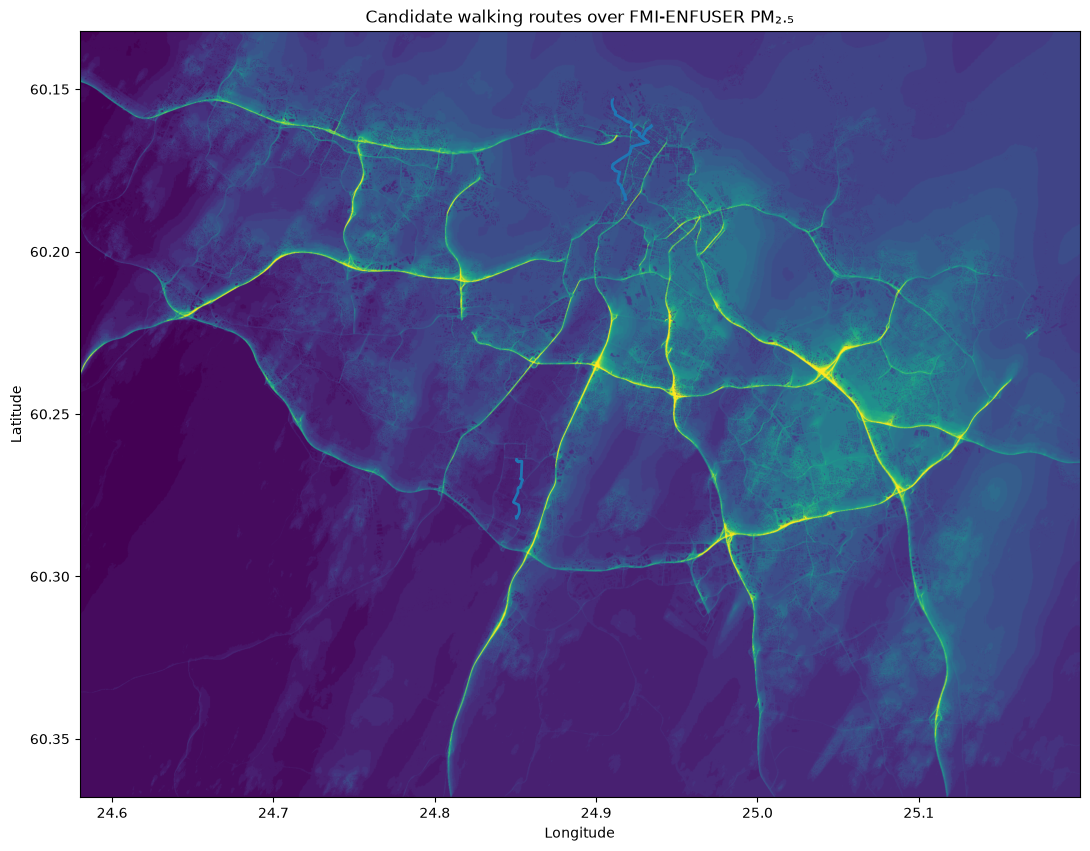

In [21]:
from rasterio.plot import show

routes_wgs84 = routes.to_crs("EPSG:4326")

with rasterio.open(helsinki.air_quality) as src:
    pm25 = src.read(5)

    fig, ax = plt.subplots(figsize=(11, 9))

    show(
        pm25,
        transform=src.transform,
        ax=ax
    )

    routes_wgs84.plot(
        ax=ax,
        linewidth=2
    )

    ax.set_title(
        "Candidate walking routes over FMI-ENFUSER PM₂.₅"
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.tight_layout()
    plt.show()

### Interpretation guardrails

At this stage, the notebook estimates exposure along **modeled shortest walking paths** for the OD pairs. It does not establish that the underlying CAFEIN mobility flows were actually made on foot, nor that travellers followed these exact paths.

For the methodology, the stronger version would combine:
1. observed or inferred active-travel trips,
2. time-specific route/trajectory geometry,
3. hourly PM₂.₅ surfaces,
4. concentration-time burden along each trip,
5. transport-poverty/equity attributes of the traveller's home area.